# Executive Summary

This project analyzes supply chain and business performance data to evaluate product demand, customer purchasing behavior, inventory management efficiency, logistics operations, and supplier performance across multiple product categories.

The analysis focuses on identifying revenue-driving products, customer demand patterns, inventory availability risks, replenishment responsiveness, transportation cost efficiency, and supplier operational performance. Key business metrics such as revenue generation, sales volume, stock levels, lead times, logistics costs, manufacturing efficiency, and defect rates are examined to uncover operational trends and potential supply chain challenges.

The project aims to provide data-driven insights that support better inventory planning, demand forecasting, supplier evaluation, logistics optimization, and overall supply chain decision-making. Through exploratory data analysis and business-focused performance evaluation, the findings help highlight operational strengths, inefficiencies, and areas requiring process improvement across the supply chain network.

## 1.Dataset Preview

Displaying the initial records of the dataset to understand the overall structure, feature composition, and available supply chain and business-related variables prior to exploratory data analysis.

In [9]:
import pandas as pd

df = pd.read_csv("../data/raw/supply_chain_data.csv")

df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,9,Carrier B,8.630339,Supplier 4,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,3,Carrier C,5.352878,Supplier 3,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,9,Carrier A,7.904846,Supplier 4,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,7,Carrier B,1.409801,Supplier 5,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


# 2.Data Understanding and Quality Assessment

Performing preliminary exploratory data analysis to understand the dataset structure, evaluate data quality, identify missing or duplicate records, and review statistical distributions before conducting business and supply chain analysis.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [11]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [12]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')

# 3.Revenue Performance Analysis

Analyzing total revenue, average product pricing, and sales volume across product categories to evaluate revenue contribution, pricing strategy, customer demand intensity, and overall market performance.

In [52]:
revenue_performance = df.groupby('Product type').agg(
    Total_Revenue=('Revenue generated', 'sum'),
    Average_Price=('Price', 'mean'),
    Products_Sold=('Number of products sold', 'sum')
)

revenue_performance['Total_Revenue'] = revenue_performance[
    'Total_Revenue'
].apply(lambda x: f"${x/1000:.1f}K")

revenue_performance['Average_Price'] = revenue_performance[
    'Average_Price'
].apply(lambda x: f"${x:.2f}")

revenue_performance['Products_Sold'] = revenue_performance[
    'Products_Sold'
].apply(lambda x: f"{x:,.0f}")

revenue_performance

,Total_Revenue,Average_Price,Products_Sold
Product type,,,
cosmetics,$161.5K,$57.36,"11,757"
haircare,$174.5K,$46.01,"13,611"
skincare,$241.6K,$47.26,"20,731"


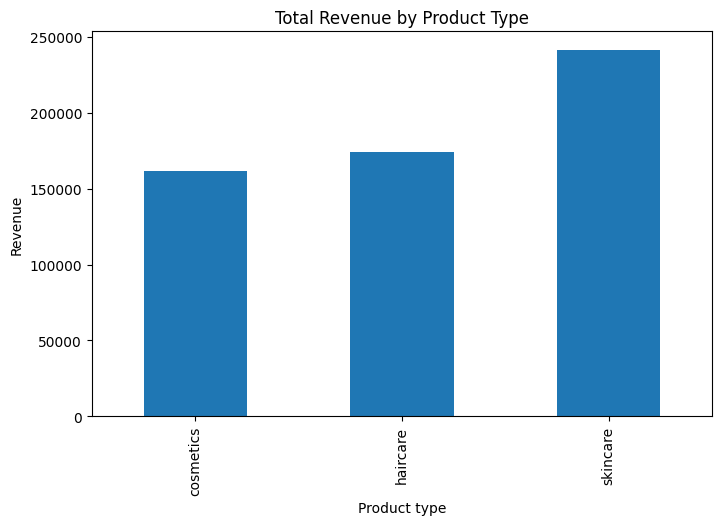

In [8]:
revenue_by_product = df.groupby('Product type')['Revenue generated'].sum()

revenue_by_product.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Total Revenue by Product Type')
plt.ylabel('Revenue')
plt.show()



### Insight

Skincare products generate the highest total revenue and sales volume, indicating strong customer demand and frequent purchasing activity across the category.

Cosmetics products maintain the highest average product price despite lower overall sales volume, suggesting that revenue generation within the category is supported more by higher pricing than by sales quantity.

Haircare products maintain relatively balanced performance across revenue, pricing, and sales volume metrics, indicating a more stable and moderate market position.

Overall, the analysis reveals differing revenue and demand patterns across product categories, with skincare operating as a volume-driven segment and cosmetics reflecting a higher-value pricing strategy.


# 4.Sales & Customer Analysis

Analyzing revenue contribution, product sales volume, order quantities, and customer demographic purchasing patterns across product categories to identify high-demand segments, customer behavior trends, demand preferences, and key revenue-driving customer groups.

In [48]:
sales_customer_analysis = filtered_df.groupby(
    ['Customer demographics', 'Product type']
)[
    ['Revenue generated', 'Number of products sold', 'Order quantities']
].sum()

sales_customer_analysis['Revenue generated'] = sales_customer_analysis[
    'Revenue generated'
].apply(lambda x: f"${x/1000:.1f}K")

sales_customer_analysis['Number of products sold'] = sales_customer_analysis[
    'Number of products sold'
].apply(lambda x: f"{x:,.0f}")

sales_customer_analysis['Order quantities'] = sales_customer_analysis[
    'Order quantities'
].apply(lambda x: f"{x:,.0f}")

sales_customer_analysis

Revenue generated Number of products sold  \
Customer demographics Product type                                             
Female                cosmetics               $69.5K                   4,012   
                      haircare                $12.7K                     936   
                      skincare                $79.2K                   7,853   
Male                  cosmetics               $21.4K                   2,304   
                      haircare                $50.6K                   2,292   
                      skincare                $54.6K                   2,911   
Non-binary            cosmetics               $26.2K                   2,607   
                      haircare                $39.0K                   2,820   
                      skincare                $51.2K                   5,153   

                                   Order quantities  
Customer demographics Product type                   
Female                cosmetics                 533  
                      haircare                   23  
                      skincare                  585  
Male                  cosmetics                 246  
                      haircare                  333  
                      skincare                  320  
Non-binary            cosmetics                 318  
                      haircare                  316  
                      skincare                  658

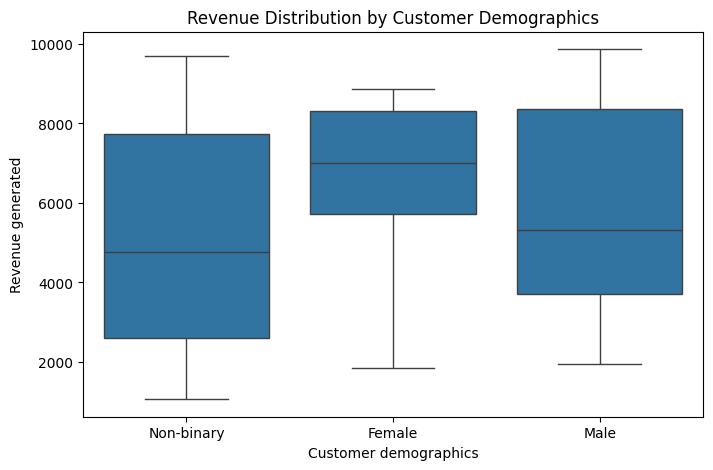

In [10]:
filtered_df = df[df['Customer demographics'] != 'Unknown']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Customer demographics',
    y='Revenue generated',
    data=filtered_df
)

plt.title('Revenue Distribution by Customer Demographics')

plt.show()

### Insight

Female customers contribute the highest revenue and sales activity within the skincare and cosmetics categories, indicating strong demand for beauty and personal care products among this demographic segment.

Male customers demonstrate relatively stronger purchasing activity within the haircare category, suggesting differing product preferences and demand patterns across customer groups.

Non-binary customers maintain relatively balanced purchasing behavior across product categories, with skincare products generating the strongest overall sales and revenue contribution within the segment.

Across most customer demographics, skincare products consistently generate the highest revenue, sales volume, and order quantities, reinforcing their position as the company’s strongest demand-driven product category.

Overall, the analysis highlights varying customer purchasing behaviors and product preferences across demographic segments, supporting the importance of customer-focused demand planning and product positioning strategies.

# 5.Inventory & Availability Analysis

Analyzing inventory levels, product availability, and sales demand across product categories to evaluate inventory efficiency, supply-demand balance, and potential stock management risks.

In [54]:
inventory_performance = df.groupby('Product type').agg(
    Average_Stock_Level=('Stock levels', 'mean'),
    Average_Availability=('Availability', 'mean'),
    Products_Sold=('Number of products sold', 'sum')
)

inventory_performance['Average_Stock_Level'] = inventory_performance[
    'Average_Stock_Level'
].apply(lambda x: f"{x:.1f}")

inventory_performance['Average_Availability'] = inventory_performance[
    'Average_Availability'
].apply(lambda x: f"{x:.1f}")

inventory_performance['Products_Sold'] = inventory_performance[
    'Products_Sold'
].apply(lambda x: f"{x:,.0f}")

inventory_performance

,Average_Stock_Level,Average_Availability,Products_Sold
Product type,,,
cosmetics,58.7,51.2,"11,757"
haircare,48.4,43.3,"13,611"
skincare,40.2,50.9,"20,731"


### Insight

Skincare products generate the highest sales volume despite maintaining comparatively lower stock levels, indicating strong customer demand and potential inventory pressure during periods of high demand.

Cosmetics products maintain the highest stock levels and product availability while generating comparatively lower sales volume, suggesting slower inventory movement and higher inventory buffering.

Haircare products demonstrate relatively balanced inventory levels, availability, and sales performance, indicating more stable inventory management and supply-demand balance.

Overall, the analysis highlights differing inventory management patterns across product categories, with skincare operating in a high-demand environment and cosmetics maintaining comparatively higher inventory reserves.

# 6.Product Replenishment Analysis

Analyzing product replenishment lead times across product categories to identify inventory responsiveness, operational delays, and potential stockout risks.

In [59]:
lead_time_by_product = df.groupby('Product type')['Lead times'].mean()

lead_time_by_product.apply(lambda x: f"{x:.1f} days")

Product type
cosmetics    15.4 days
haircare     15.5 days
skincare     16.7 days
Name: Lead times, dtype: str

### Insight

Haircare and skincare products maintain comparatively higher replenishment lead times than cosmetics products, indicating slower inventory responsiveness across these categories.

Skincare products combine strong sales demand with lower stock levels and longer lead times, increasing inventory pressure and the risk of stock shortages during high-demand periods.

Haircare products also demonstrate extended lead times, which may reduce replenishment flexibility and slow inventory turnover.

In contrast, cosmetics products maintain shorter lead times, supporting faster inventory replenishment and improved responsiveness to changing customer demand.

Overall, the analysis highlights the importance of efficient replenishment planning and inventory management for skincare and haircare product categories.


# 7.Logistics & Carrier Analysis

Analyzing shipping carrier performance, transportation efficiency, delivery responsiveness, and logistics cost patterns across the supply chain network.

## 7.1 Carrier Performance Analysis

Evaluating shipping carrier efficiency based on shipping costs and delivery times to identify operationally efficient logistics providers.

In [61]:
carrier_performance = df.groupby('Shipping carriers').agg(
    Average_Shipping_Cost=('Shipping costs', 'mean'),
    Average_Shipping_Time=('Shipping times', 'mean')
)

carrier_performance['Average_Shipping_Cost'] = carrier_performance[
    'Average_Shipping_Cost'
].apply(lambda x: f"${x:.2f}")

carrier_performance['Average_Shipping_Time'] = carrier_performance[
    'Average_Shipping_Time'
].apply(lambda x: f"{x:.1f} days")

carrier_performance

,Average_Shipping_Cost,Average_Shipping_Time
Shipping carriers,,
Carrier A,$5.55,6.1 days
Carrier B,$5.51,5.3 days
Carrier C,$5.60,6.0 days


### Insight

Average shipping costs remain relatively consistent across all shipping carriers, with Carrier C showing slightly higher average shipping costs compared to Carriers A and B. However, the differences are marginal, suggesting relatively standardized pricing across logistics providers.

Carrier B appears to provide the most operationally efficient logistics performance, maintaining the lowest average shipping cost while also delivering the shortest average shipping times among all carriers.

Although Carriers A and C charge only slightly higher shipping costs, both carriers exhibit longer average delivery times compared to Carrier B. This may indicate comparatively lower logistics efficiency or slower transportation performance.

## 7.2 Transportation Mode Analysis

Analyzing transportation modes based on logistics costs and shipping times to evaluate transportation efficiency and operational tradeoffs across the supply chain.

In [63]:
transportation_performance = df.groupby(
    'Transportation modes'
).agg(
    Average_Logistics_Cost=('Costs', 'mean')
)

transportation_performance['Average_Logistics_Cost'] = transportation_performance[
    'Average_Logistics_Cost'
].apply(lambda x: f"${x:.2f}")

transportation_performance

,Average_Logistics_Cost
Transportation modes,
Air,$561.71
Rail,$541.75
Road,$553.39
Sea,$417.82


### Insight

Logistics costs vary across transportation modes, indicating differences in operational efficiency and transportation cost structures within the supply chain network.

Air transportation maintains the highest logistics costs, reflecting the premium operational expense associated with faster and more responsive transportation methods.

Sea transportation demonstrates comparatively lower logistics costs, suggesting stronger cost efficiency for large-scale or long-distance transportation operations.

Road and rail transportation maintain relatively balanced cost structures, supporting stable transportation operations across the logistics network.

Overall, the analysis highlights differing transportation cost patterns across logistics modes and the operational tradeoffs involved in transportation planning.


# 8.Supplier Performance Analysis

Analyzing supplier manufacturing efficiency, production capacity, operational responsiveness, production cost structures, and product quality performance across the supplier network.

In [71]:
supplier_performance = df.groupby('Supplier name').agg(
    Average_Production_Volume=('Production volumes', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean'),
    Average_Defect_Rate=('Defect rates', 'mean')
)

supplier_performance['Average_Production_Volume'] = supplier_performance[
    'Average_Production_Volume'
].apply(lambda x: f"{x:.0f}")

supplier_performance['Average_Manufacturing_Lead_Time'] = supplier_performance[
    'Average_Manufacturing_Lead_Time'
].apply(lambda x: f"{x:.1f} days")

supplier_performance['Average_Manufacturing_Cost'] = supplier_performance[
    'Average_Manufacturing_Cost'
].apply(lambda x: f"${x:.2f}")

supplier_performance['Average_Defect_Rate'] = supplier_performance[
    'Average_Defect_Rate'
].apply(lambda x: f"{x:.2f}%")

supplier_performance

,Average_Production_Volume,Average_Manufacturing_Lead_Time,Average_Manufacturing_Cost,Average_Defect_Rate
Supplier name,,,,
Supplier 1,502,12.6 days,$45.25,1.80%
Supplier 2,641,15.6 days,$41.62,2.36%
Supplier 3,533,14.9 days,$43.63,2.47%
Supplier 4,653,15.3 days,$62.71,2.34%
Supplier 5,521,16.3 days,$44.77,2.67%


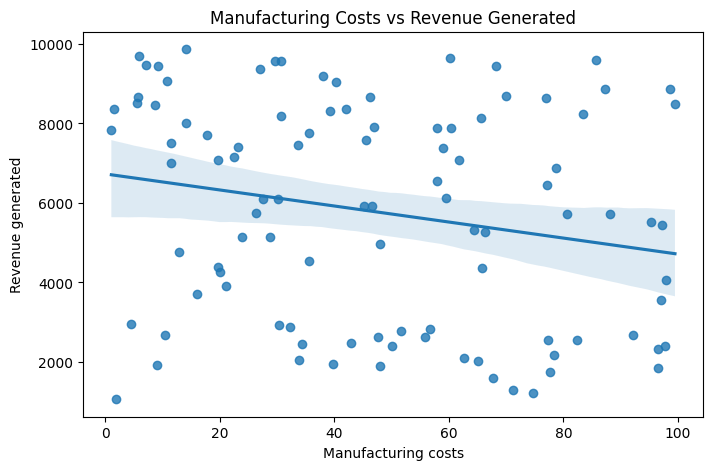

In [19]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Manufacturing costs',
    y='Revenue generated',
    data=df
)

plt.title('Manufacturing Costs vs Revenue Generated')

plt.show()

## Insight

Supplier performance varies across production capacity, manufacturing efficiency, production costs, and defect rates within the supply chain network.

Some suppliers maintain higher production volumes alongside shorter manufacturing lead times and lower defect rates, indicating stronger operational efficiency and manufacturing consistency.

Other suppliers demonstrate comparatively longer manufacturing cycles, higher production costs, or increased defect rates, which may contribute to slower replenishment responsiveness and greater operational quality risks.

Manufacturing costs also vary across suppliers, highlighting differences in production efficiency and cost management practices within the supplier network.

Additionally, the relationship between manufacturing costs and revenue generation suggests that higher manufacturing costs do not consistently translate into higher revenue performance. While certain high-cost products generate strong revenue, several products with elevated manufacturing costs exhibit comparatively moderate revenue levels, indicating potential inefficiencies in pricing strategy, cost optimization, or product profitability.

Overall, the analysis highlights operational differences across suppliers and emphasizes the importance of balancing production capacity, manufacturing efficiency, cost control, and product quality within the supply chain.

# 9.Correlation Analysis

Purpose:

Analyzing relationships between demand, inventory levels, lead times, pricing, logistics costs, manufacturing costs, and operational performance metrics to identify business trends, operational dependencies, and supply chain efficiency patterns.


In [72]:
numeric_columns = [
    'Price',
    'Availability',
    'Number of products sold',
    'Revenue generated',
    'Stock levels',
    'Lead times',
    'Order quantities',
    'Shipping times',
    'Shipping costs',
    'Production volumes',
    'Manufacturing lead time',
    'Manufacturing costs',
    'Defect rates',
    'Costs'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
Price,1.000000,0.019083,0.005739,0.038424,0.078261,0.044855,0.095819,0.071942,0.058543,-0.124575,-0.301313,-0.184123,-0.147247,0.088501
Availability,0.019083,1.000000,0.087496,-0.075170,-0.025900,0.170439,0.143769,-0.051377,-0.044179,0.050134,0.065333,0.134652,0.040626,-0.027315
Number of products sold,0.005739,0.087496,1.000000,-0.001641,0.022189,-0.046419,0.015992,0.087315,0.044285,0.187945,-0.048939,0.034284,-0.082726,-0.036951
Revenue generated,0.038424,-0.075170,-0.001641,1.000000,-0.158480,-0.057296,0.029422,-0.109211,-0.072892,-0.037441,0.014073,-0.214025,-0.125335,0.027252
Stock levels,0.078261,-0.025900,0.022189,-0.158480,1.000000,0.072571,-0.111455,-0.094883,0.072907,0.043763,-0.050592,0.033243,-0.149478,-0.012088
Lead times,0.044855,0.170439,-0.046419,-0.057296,0.072571,1.000000,0.105459,-0.045156,-0.120746,-0.145324,0.003364,-0.024441,0.015681,0.243686
Order quantities,0.095819,0.143769,0.015992,0.029422,-0.111455,0.105459,1.000000,-0.002561,0.004261,-0.086567,0.112347,-0.026784,0.018986,0.167306
Shipping times,0.071942,-0.051377,0.087315,-0.109211,-0.094883,-0.045156,-0.002561,1.000000,0.045108,-0.060470,-0.016953,0.029132,-0.036673,-0.045541
Shipping costs,0.058543,-0.044179,0.044285,-0.072892,0.072907,-0.120746,0.004261,0.045108,1.000000,-0.097979,-0.005653,0.005984,0.083139,0.051671
Production volumes,-0.124575,0.050134,0.187945,-0.037441,0.043763,-0.145324,-0.086567,-0.060470,-0.097979,1.000000,0.184457,0.051504,0.118853,-0.074927


Matplotlib is building the font cache; this may take a moment.


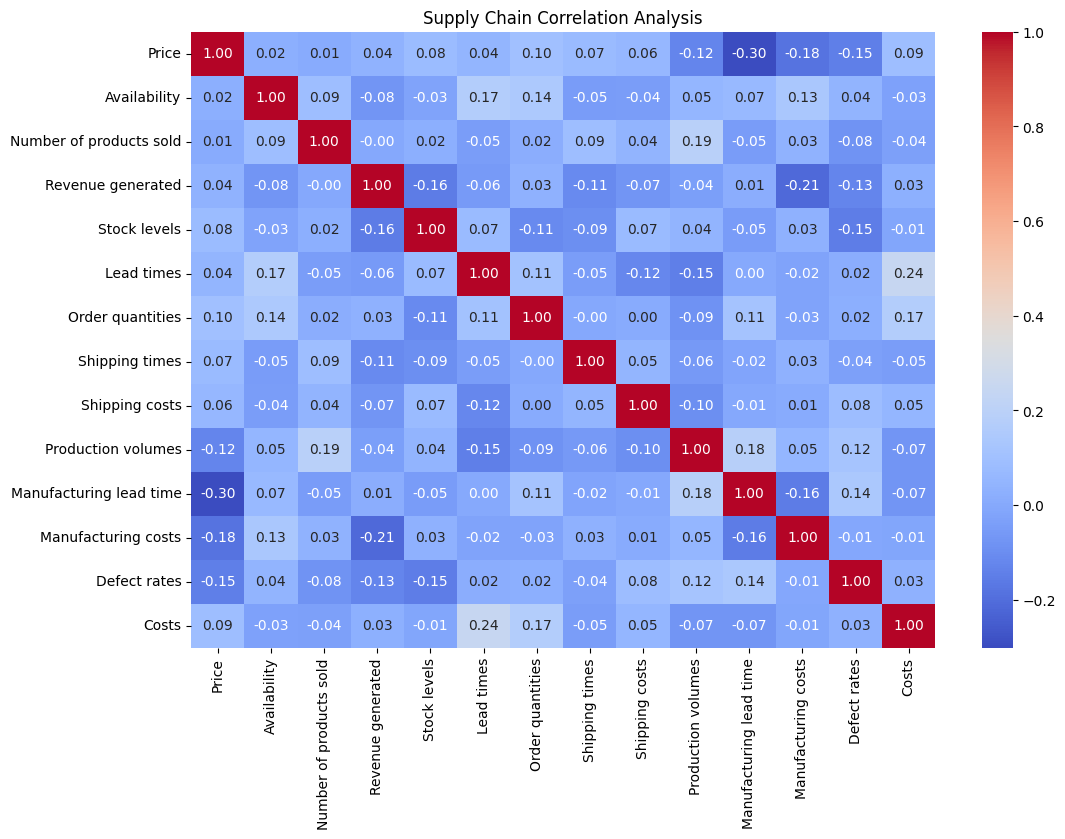

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Supply Chain Correlation Analysis')

plt.show()

### Insight

The correlation analysis helps identify relationships between operational, inventory, sales, and logistics variables across the supply chain network.

Strong positive relationships between revenue generation, sales volume, and order quantities indicate that customer demand remains a primary driver of overall business performance.

Relationships between stock levels, availability, and lead times help highlight how replenishment responsiveness and inventory management may influence product availability and operational efficiency.

The analysis also provides additional visibility into how manufacturing, logistics, and transportation-related variables interact within the broader supply chain process.

# 10.Recommendations

Based on the analysis findings, several operational and business improvement opportunities can be identified across product management, inventory planning, logistics operations, and supplier performance.

- Strengthen inventory monitoring and replenishment planning for skincare products due to consistently high sales demand, lower average stock levels, and comparatively longer replenishment lead times.

- Evaluate inventory allocation strategies for cosmetics products to reduce potential overstocking and improve inventory turnover efficiency while maintaining product availability.

- Improve demand forecasting and replenishment responsiveness for haircare and skincare categories to minimize operational delays and reduce potential stockout risks during periods of increased customer demand.

- Optimize transportation and logistics cost management by reviewing transportation modes and shipping carrier performance to identify more cost-efficient logistics strategies.

- Continuously monitor supplier manufacturing lead times, production quality, and defect rates to identify operational risks and improve supplier reliability within the supply chain network.

- Utilize customer purchasing behavior insights to support more targeted product positioning, inventory distribution, and customer engagement strategies across different demographic segments.

Overall, the findings highlight the importance of balancing customer demand, inventory responsiveness, supplier efficiency, and logistics performance to improve operational stability and overall supply chain effectiveness.

# Conclusion

The supply chain analysis identified important operational patterns across product categories, customer segments, inventory management, supplier performance, and logistics operations.

The findings reveal that skincare products represent the company’s strongest demand-driven category, generating the highest sales volume and total revenue despite maintaining comparatively lower inventory levels and longer replenishment lead times. In contrast, cosmetics products demonstrate stronger pricing performance and higher inventory availability, while haircare products maintain relatively balanced operational performance across most business metrics.

The analysis also highlighted opportunities for improving inventory optimization, replenishment responsiveness, supplier efficiency, and logistics cost management. Correlation analysis further provided insights into relationships between sales, inventory, lead times, production activity, and operational costs across the supply chain network.

Overall, this project demonstrates how exploratory data analysis and business-focused analytics can support better supply chain decision-making, operational efficiency, demand forecasting, inventory planning, and supplier performance evaluation.